In [19]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
df=pd.read_csv("Books_Data_Clean.csv")

In [2]:
df.head()

,index,Publishing Year,Book Name,Author,language_code,Author_Rating,Book_average_rating,Book_ratings_count,genre,gross sales,publisher revenue,sale price,sales rank,Publisher,units sold
0,0,1975.0,Beowulf,"Unknown, Seamus Heaney",en-US,Novice,3.42,155903,genre fiction,34160.0,20496.0,4.88,1,HarperCollins Publishers,7000
1,1,1987.0,Batman: Year One,"Frank Miller, David Mazzucchelli, Richmond Lew...",eng,Intermediate,4.23,145267,genre fiction,12437.5,7462.5,1.99,2,HarperCollins Publishers,6250
2,2,2015.0,Go Set a Watchman,Harper Lee,eng,Novice,3.31,138669,genre fiction,47795.0,28677.0,8.69,3,"Amazon Digital Services, Inc.",5500
3,3,2008.0,When You Are Engulfed in Flames,David Sedaris,en-US,Intermediate,4.04,150898,fiction,41250.0,24750.0,7.50,3,Hachette Book Group,5500
4,4,2011.0,Daughter of Smoke & Bone,Laini Taylor,eng,Intermediate,4.04,198283,genre fiction,37952.5,22771.5,7.99,4,Penguin Group (USA) LLC,4750


In [4]:
df.describe()

,index,Publishing Year,Book_average_rating,Book_ratings_count,gross sales,publisher revenue,sale price,sales rank,units sold
count,1070.000000,1069.000000,1070.000000,1070.000000,1070.000000,1070.000000,1070.000000,1070.000000,1070.000000
mean,534.500000,1971.377923,4.007000,94909.913084,1856.622944,843.281030,4.869561,611.652336,9676.980374
std,309.026698,185.080257,0.247244,31513.242518,3936.924240,2257.596743,3.559919,369.849830,15370.571306
min,0.000000,-560.000000,2.970000,27308.000000,104.940000,0.000000,0.990000,1.000000,106.000000
25%,267.250000,1985.000000,3.850000,70398.000000,372.465000,0.000000,1.990000,287.500000,551.250000
50%,534.500000,2003.000000,4.015000,89309.000000,809.745000,273.078000,3.990000,595.500000,3924.000000
75%,801.750000,2010.000000,4.170000,113906.500000,1487.957500,721.180500,6.990000,932.500000,5312.250000
max,1069.000000,2016.000000,4.770000,206792.000000,47795.000000,28677.000000,33.860000,1273.000000,61560.000000


In [13]:
df=df[df["Publishing Year"]>1990]

In [14]:
df.isna().sum()

index                   0
Publishing Year         0
Book Name              17
Author                  0
language_code          31
Author_Rating           0
Book_average_rating     0
Book_ratings_count      0
genre                   0
gross sales             0
publisher revenue       0
sale price              0
sales rank              0
Publisher               0
units sold              0
dtype: int64

In [8]:
df.dropna(subset="Book Name",inplace=True)

In [12]:
df.nunique()

index                  1070
Publishing Year         150
Book Name              1045
Author                  735
language_code             8
Author_Rating             4
Book_average_rating     134
Book_ratings_count     1064
genre                     4
gross sales             831
publisher revenue       610
sale price              149
sales rank              865
Publisher                 9
units sold              491
dtype: int64

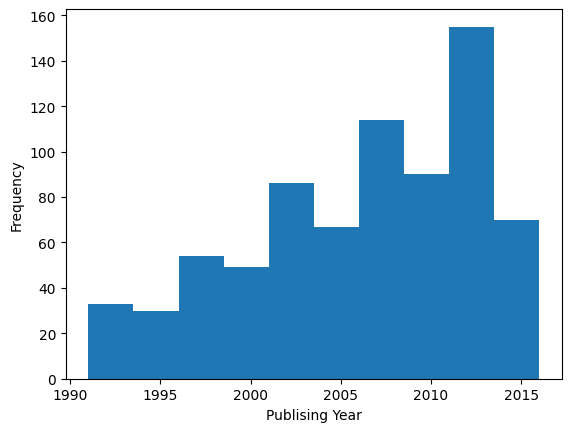

In [15]:
plt.hist(df["Publishing Year"])
plt.xlabel("Publising Year")
plt.ylabel("Frequency")
plt.show()

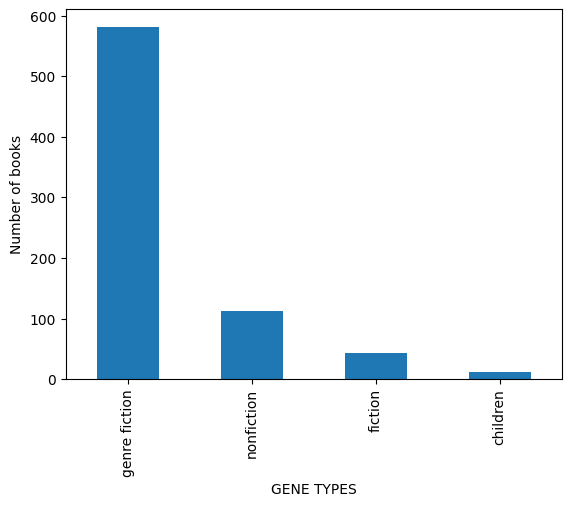

In [17]:
df['genre'].value_counts().plot(kind='bar')
plt.xlabel("GENE TYPES")
plt.ylabel("Number of books")
plt.show()

In [18]:
df.groupby('Author')['Book_average_rating'].mean().sort_values(ascending=False)

Author
George R.R. Martin                4.560000
Sarah J. Maas                     4.526000
Kate Egan                         4.510000
Hiromu Arakawa, Akira Watanabe    4.490000
Cassandra Clare                   4.480000
                                    ...   
Chetan Bhagat                     3.273333
Audrey Niffenegger                3.230000
Herman Koch, Sam Garrett          3.220000
P.D. James                        3.210000
Sue Monk Kidd                     3.100000
Name: Book_average_rating, Length: 479, dtype: float64

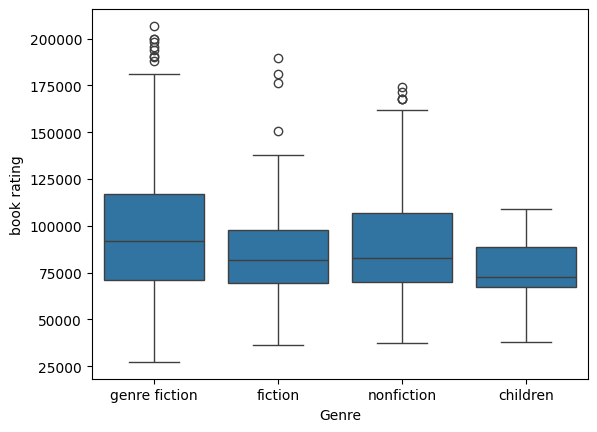

In [21]:
sns.boxplot(x="genre",y='Book_ratings_count',data=df)
plt.xlabel('Genre')
plt.ylabel("book rating")
plt.show()

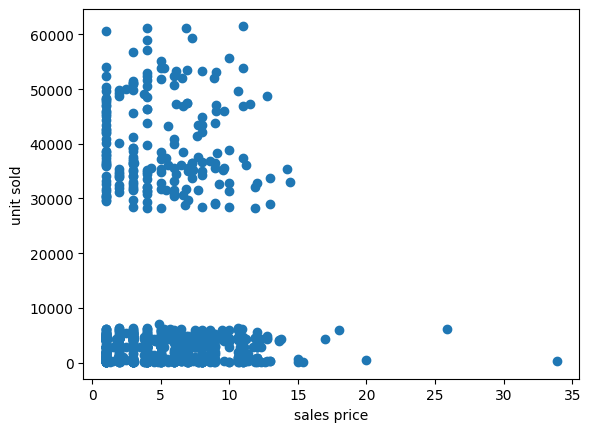

In [22]:
plt.scatter(df["sale price"],df['units sold'])
plt.xlabel("sales price")
plt.ylabel('unit sold')
plt.show()

In [24]:
df['language_code'].value_counts().sort_values(ascending=True)

language_code
nl         1
spa        2
ara        2
fre        4
en-CA      7
en-GB     30
en-US    234
eng      737
Name: count, dtype: int64

<Axes: >

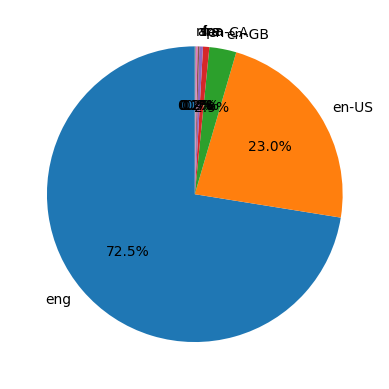

In [28]:
df['language_code'].value_counts().plot(kind='pie',autopct="%1.1f%%",startangle=90)

In [31]:
df.groupby("Publisher ")['publisher revenue'].sum().sort_values(ascending=False)

Publisher 
Penguin Group (USA) LLC                 213817.482
Random House LLC                        189585.222
Amazon Digital Services,  Inc.          148244.178
Hachette Book Group                     137874.498
HarperCollins Publishers                128478.258
Simon and Schuster Digital Sales Inc     46988.352
Macmillan                                32356.236
HarperCollins Publishing                  2830.806
HarperCollins Christian Publishing        2135.670
Name: publisher revenue, dtype: float64

In [33]:
df.groupby("Author_Rating")['Book_ratings_count'].mean().sort_values(ascending=True)

Author_Rating
Excellent        82905.889503
Novice           88728.166667
Famous           97414.301887
Intermediate    101946.995200
Name: Book_ratings_count, dtype: float64

Text(0, 0.5, 'no of ratings')

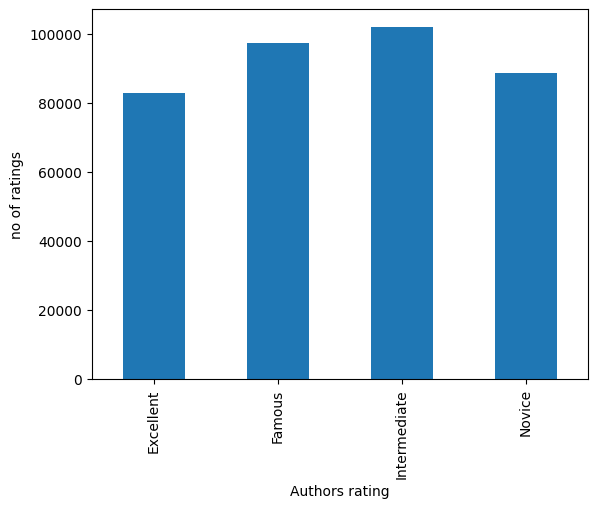

In [35]:
df.groupby("Author_Rating")['Book_ratings_count'].mean().plot(kind='bar')
plt.xlabel("Authors rating")
plt.ylabel("no of ratings")

In [37]:
df.groupby("Author_Rating")['Book_ratings_count'].max()

Author_Rating
Excellent       167848
Famous          206792
Intermediate    199872
Novice          155903
Name: Book_ratings_count, dtype: int64

In [38]:
df.groupby("Author_Rating")['Book_ratings_count'].count()

Author_Rating
Excellent       362
Famous           53
Intermediate    625
Novice           30
Name: Book_ratings_count, dtype: int64

In [36]:
df.groupby('language_code').size().sort_values(ascending=True)

language_code
nl         1
ara        2
spa        2
fre        4
en-CA      7
en-GB     30
en-US    234
eng      737
dtype: int64

In [40]:
total_gross_sales=df.groupby("Author")['gross sales'].sum()
total_gross_sales

Author
A.A. Milne, Ernest H. Shepard                       214.92
A.S.A. Harrison                                     784.16
Abbi Glines                                        2990.16
Adam Johnson                                        108.90
Adam Mansbach, Ricardo CortÃ©s                      113.85
                                                    ...   
William Styron                                      220.89
Yana Toboso, Tomo Kimura                           1366.86
Zadie Smith                                         167.31
Ø£Ø­Ù„Ø§Ù… Ù…Ø³ØªØºØ§Ù†Ù…ÙŠ, Ahlam Mosteghanemi    1200.10
Ø£Ø­Ù…Ø¯ Ù…Ø±Ø§Ø¯                                  1128.87
Name: gross sales, Length: 735, dtype: float64

<Axes: xlabel='Author'>

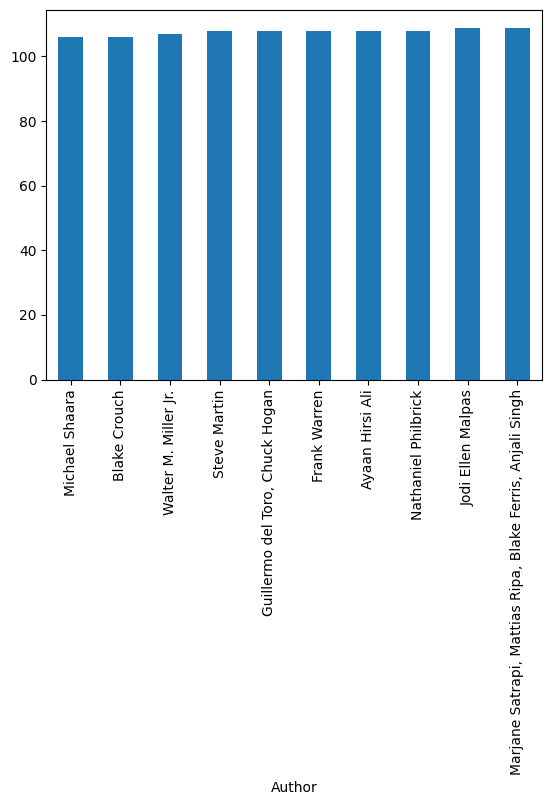

In [ ]:
total_gross_sales.sort_values(ascending=False).head(10).plot(kind='bar')